DATA LOADED
X_train: (24006, 32)
y_train: (24006,)
X_val  : (8002, 32)
y_val  : (8002,)
X_test : (8002, 32)
y_test : (8002,)

CLASS DISTRIBUTION

Training:
label
0    21000
1     3006
Name: count, dtype: int64

Validation:
label
0    7000
1    1002
Name: count, dtype: int64

Test:
label
0    7000
1    1002
Name: count, dtype: int64

BASELINE DECISION TREE
Training time: 0.1107 seconds

TRAINING SET
Accuracy  : 0.999958
Precision : 1.000000
Recall    : 0.999667
F1-score  : 0.999834
ROC-AUC   : 1.000000
PR-AUC    : 1.000000

Classification Report:
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000     21000
     Anomaly     1.0000    0.9997    0.9998      3006

    accuracy                         1.0000     24006
   macro avg     1.0000    0.9998    0.9999     24006
weighted avg     1.0000    1.0000    1.0000     24006


VALIDATION SET
Accuracy  : 0.953012
Precision : 0.799235
Recall    : 0.834331
F1-score  : 0.816406
ROC-AUC   : 0.902166


,experiment,max_depth,min_samples_split,min_samples_leaf,accuracy,precision,recall,f1,roc_auc,pr_auc,training_time_sec
0,10,10.0,5,5,0.975756,0.997537,0.808383,0.893054,0.981628,0.898568,0.066390
1,3,10.0,2,1,0.975631,0.996310,0.808383,0.892562,0.980762,0.897669,0.047408
2,4,15.0,2,1,0.975006,0.987835,0.810379,0.890351,0.977072,0.906357,0.072918
3,2,5.0,2,1,0.974881,1.000000,0.799401,0.888519,0.979238,0.881409,0.051338
4,11,15.0,5,5,0.974506,0.984223,0.809381,0.888280,0.974880,0.909173,0.069402
5,12,20.0,10,5,0.971007,0.947674,0.813373,0.875403,0.964088,0.906084,0.074955
6,9,NaN,2,10,0.969133,0.928490,0.816367,0.868826,0.947153,0.895006,0.078519
7,5,20.0,2,1,0.968008,0.919101,0.816367,0.864693,0.959493,0.853682,0.068135
8,8,NaN,2,5,0.964384,0.884244,0.823353,0.852713,0.934927,0.880667,0.087354
9,7,NaN,10,1,0.962384,0.870116,0.822355,0.845562,0.920376,0.828854,0.080614



BEST DECISION TREE CONFIGURATION
experiment           10.000000
max_depth            10.000000
min_samples_split     5.000000
min_samples_leaf      5.000000
accuracy              0.975756
precision             0.997537
recall                0.808383
f1                    0.893054
roc_auc               0.981628
pr_auc                0.898568
training_time_sec     0.066390
Name: 9, dtype: float64

Selected parameters:
{'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 5}

Parameter types:
max_depth: 10 (int)
min_samples_split: 5 (int)
min_samples_leaf: 5 (int)

TRAINING BEST DECISION TREE
Training time: 0.0690 seconds

BEST MODEL - TRAINING SET
Accuracy  : 0.974298
Precision : 0.997916
Recall    : 0.796407
F1-score  : 0.885846
ROC-AUC   : 0.981536
PR-AUC    : 0.894300

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9717    0.9998    0.9855     21000
     Anomaly     0.9979    0.7964    0.8858      3006

    accuracy           

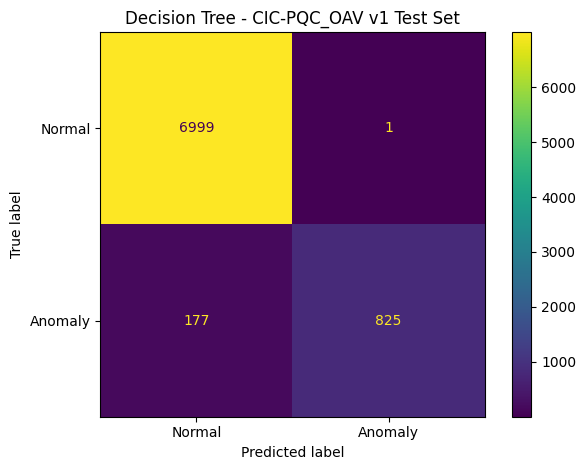


FEATURE IMPORTANCE


,feature,importance
0,e9_conn_outcome_Success,0.576513
1,e6b_flow_duration_ms,0.265012
2,e6_time_char,0.088971
3,e2_client_record_len,0.038244
4,e1_alg_suite_mlkem768,0.018979
5,e2_server_record_len,0.011595
6,e4_entropy_h,0.000686
7,e5_entropy_c,0.000000
8,e2_client_size,0.000000
9,e3_cert_parsed,0.000000


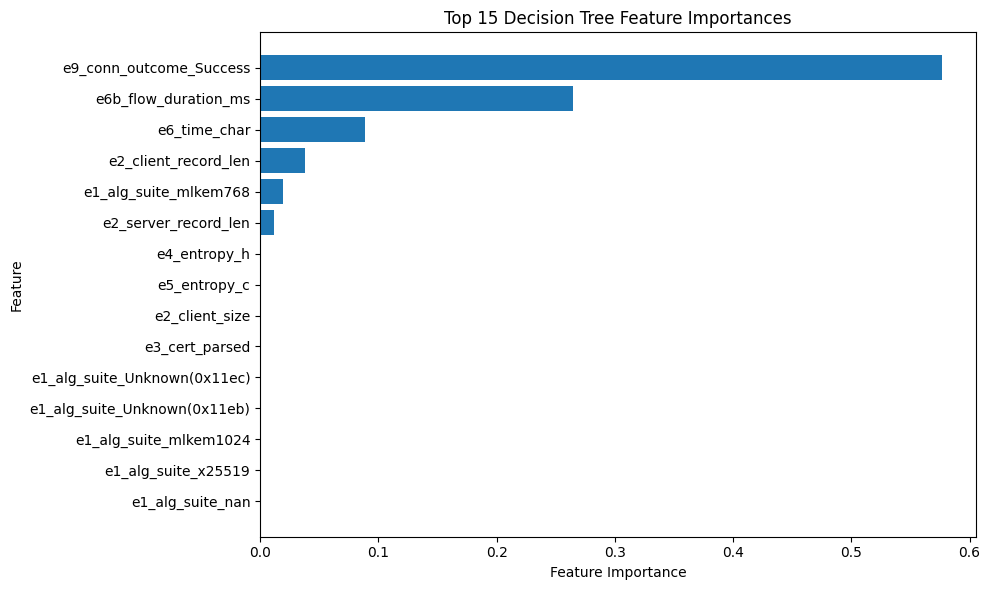


FINAL DECISION TREE RESULTS


,Metric,Training,Validation,Test
0,Accuracy,0.974298,0.975756,0.977756
1,Precision,0.997916,0.997537,0.998789
2,Recall,0.796407,0.808383,0.823353
3,F1-score,0.885846,0.893054,0.902626
4,ROC-AUC,0.981536,0.981628,0.982872
5,PR-AUC,0.894300,0.898568,0.907060
6,Training Time (sec),0.069031,NaN,NaN



Results saved:
1. decision_tree_hyperparameter_results.csv
2. decision_tree_final_results.csv
3. decision_tree_feature_importance.csv

FINAL MODEL SUMMARY
Algorithm       : Decision Tree
Criterion       : Gini
Random state    : 42
Max depth       : 10
Min samples split: 5
Min samples leaf : 5

Test Accuracy   : 0.977756
Test Precision  : 0.998789
Test Recall     : 0.823353
Test F1-score   : 0.902626
Test ROC-AUC    : 0.982872
Test PR-AUC     : 0.907060


In [2]:
# ============================================================
# CIC-PQC_OAV v1
# DECISION TREE CLASSIFIER
#
# Uses the PREPROCESSED datasets generated previously:
#
# X_train_preprocessed.csv
# X_val_preprocessed.csv
# X_test_preprocessed.csv
# y_train.csv
# y_val.csv
# y_test.csv
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)

import matplotlib.pyplot as plt


# ============================================================
# 2. LOAD PREPROCESSED DATA
# ============================================================

X_train = pd.read_csv("X_train_preprocessed.csv")
X_val   = pd.read_csv("X_val_preprocessed.csv")
X_test  = pd.read_csv("X_test_preprocessed.csv")

y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_val   = pd.read_csv("y_val.csv").squeeze("columns")
y_test  = pd.read_csv("y_test.csv").squeeze("columns")


print("=" * 70)
print("DATA LOADED")
print("=" * 70)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ============================================================
# 3. CHECK CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

print("\nTraining:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


# ============================================================
# 4. DEFINE METRIC FUNCTION
# ============================================================

def evaluate_model(model, X, y, dataset_name):
    """
    Evaluate a trained binary classification model.
    """

    predictions = model.predict(X)

    # Probability for positive class
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)[:, 1]
    else:
        probabilities = None

    accuracy = accuracy_score(y, predictions)

    precision = precision_score(
        y,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )

    if probabilities is not None:
        roc_auc = roc_auc_score(
            y,
            probabilities
        )

        pr_auc = average_precision_score(
            y,
            probabilities
        )
    else:
        roc_auc = np.nan
        pr_auc = np.nan


    print("\n" + "=" * 70)
    print(dataset_name.upper())
    print("=" * 70)

    print(f"Accuracy  : {accuracy:.6f}")
    print(f"Precision : {precision:.6f}")
    print(f"Recall    : {recall:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC-AUC   : {roc_auc:.6f}")
    print(f"PR-AUC    : {pr_auc:.6f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y,
            predictions,
            target_names=["Normal", "Anomaly"],
            digits=4,
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }


# ============================================================
# 5. BASELINE DECISION TREE
# ============================================================

print("\n" + "=" * 70)
print("BASELINE DECISION TREE")
print("=" * 70)

start_time = time.time()

dt_baseline = DecisionTreeClassifier(
    random_state=42
)

dt_baseline.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.4f} seconds")

# Evaluate
baseline_train_metrics = evaluate_model(
    dt_baseline,
    X_train,
    y_train,
    "Training Set"
)

baseline_val_metrics = evaluate_model(
    dt_baseline,
    X_val,
    y_val,
    "Validation Set"
)


# ============================================================
# 6. DECISION TREE HYPERPARAMETER EXPERIMENT
# ============================================================
#
# The paper performs comparative ML experiments.
#
# We evaluate several Decision Tree configurations using the
# VALIDATION SET.
#
# The TEST SET is deliberately NOT used here.
# ============================================================

print("\n" + "=" * 70)
print("DECISION TREE HYPERPARAMETER EXPERIMENT")
print("=" * 70)


parameter_grid = [

    # Default-like tree
    {
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    # Shallow trees
    {
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    {
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    {
        "max_depth": 15,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    {
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    # Larger minimum split
    {
        "max_depth": None,
        "min_samples_split": 5,
        "min_samples_leaf": 1
    },

    {
        "max_depth": None,
        "min_samples_split": 10,
        "min_samples_leaf": 1
    },

    # Minimum leaf size
    {
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 5
    },

    {
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 10
    },

    # More regularized
    {
        "max_depth": 10,
        "min_samples_split": 5,
        "min_samples_leaf": 5
    },

    {
        "max_depth": 15,
        "min_samples_split": 5,
        "min_samples_leaf": 5
    },

    {
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 5
    }
]


results = []


for i, params in enumerate(parameter_grid, start=1):

    print(
        f"\nExperiment {i}/{len(parameter_grid)}"
    )

    print(params)

    start_time = time.time()

    model = DecisionTreeClassifier(
        criterion="gini",
        random_state=42,
        **params
    )

    model.fit(
        X_train,
        y_train
    )

    train_time = time.time() - start_time

    # Validation predictions
    val_predictions = model.predict(X_val)

    val_probabilities = model.predict_proba(
        X_val
    )[:, 1]

    accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    precision = precision_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val,
        val_probabilities
    )

    pr_auc = average_precision_score(
        y_val,
        val_probabilities
    )

    results.append({
        "experiment": i,
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "training_time_sec": train_time
    })


# ============================================================
# 7. DISPLAY ALL EXPERIMENTS
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("ALL DECISION TREE EXPERIMENTS")
print("=" * 70)

display(
    results_df.sort_values(
        "f1",
        ascending=False
    ).reset_index(drop=True)
)


# ============================================================
# 8. SELECT BEST CONFIGURATION
# ============================================================

best_index = results_df["f1"].idxmax()

best_max_depth = results_df.loc[best_index, "max_depth"]

# Convert numpy/pandas float such as np.float64(10.0)
# back to a Python int, while preserving None
if pd.isna(best_max_depth):
    best_max_depth = None
else:
    best_max_depth = int(best_max_depth)

best_params = {
    "max_depth": best_max_depth,
    "min_samples_split": int(
        results_df.loc[best_index, "min_samples_split"]
    ),
    "min_samples_leaf": int(
        results_df.loc[best_index, "min_samples_leaf"]
    )
}

print("\n" + "=" * 70)
print("BEST DECISION TREE CONFIGURATION")
print("=" * 70)

print(results_df.loc[best_index])

print("\nSelected parameters:")
print(best_params)

print("\nParameter types:")
for key, value in best_params.items():
    print(
        f"{key}: {value!r} "
        f"({type(value).__name__})"
    )


# ============================================================
# 9. RETRAIN BEST MODEL
# ============================================================

print("\n" + "=" * 70)
print("TRAINING BEST DECISION TREE")
print("=" * 70)

start_time = time.time()

best_dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    **best_params
)

best_dt.fit(
    X_train,
    y_train
)

best_training_time = time.time() - start_time

print(
    f"Training time: "
    f"{best_training_time:.4f} seconds"
)


# ============================================================
# 10. EVALUATE BEST MODEL ON TRAINING SET
# ============================================================

best_train_metrics = evaluate_model(
    best_dt,
    X_train,
    y_train,
    "Best Model - Training Set"
)


# ============================================================
# 11. EVALUATE BEST MODEL ON VALIDATION SET
# ============================================================

best_val_metrics = evaluate_model(
    best_dt,
    X_val,
    y_val,
    "Best Model - Validation Set"
)


# ============================================================
# 12. FINAL TEST EVALUATION
# ============================================================
#
# IMPORTANT:
# The test set is used ONLY after selecting the model.
# ============================================================

best_test_metrics = evaluate_model(
    best_dt,
    X_test,
    y_test,
    "Best Model - TEST SET"
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("TEST SET CONFUSION MATRIX")
print("=" * 70)

y_test_pred = best_dt.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm)

print("\nInterpretation:")
print("TN =", cm[0, 0])
print("FP =", cm[0, 1])
print("FN =", cm[1, 0])
print("TP =", cm[1, 1])


# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot()

plt.title(
    "Decision Tree - CIC-PQC_OAV v1 Test Set"
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)


# ============================================================
# 15. PLOT TOP 15 FEATURES
# ============================================================

top_n = 15

top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Decision Tree Feature Importances"
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. FINAL RESULTS TABLE
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Training Time (sec)"
    ],

    "Training": [
        best_train_metrics["accuracy"],
        best_train_metrics["precision"],
        best_train_metrics["recall"],
        best_train_metrics["f1"],
        best_train_metrics["roc_auc"],
        best_train_metrics["pr_auc"],
        best_training_time
    ],

    "Validation": [
        best_val_metrics["accuracy"],
        best_val_metrics["precision"],
        best_val_metrics["recall"],
        best_val_metrics["f1"],
        best_val_metrics["roc_auc"],
        best_val_metrics["pr_auc"],
        np.nan
    ],

    "Test": [
        best_test_metrics["accuracy"],
        best_test_metrics["precision"],
        best_test_metrics["recall"],
        best_test_metrics["f1"],
        best_test_metrics["roc_auc"],
        best_test_metrics["pr_auc"],
        np.nan
    ]
})


print("\n" + "=" * 70)
print("FINAL DECISION TREE RESULTS")
print("=" * 70)

display(
    final_results.round(6)
)


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "decision_tree_hyperparameter_results.csv",
    index=False
)

final_results.to_csv(
    "decision_tree_final_results.csv",
    index=False
)

feature_importance.to_csv(
    "decision_tree_feature_importance.csv",
    index=False
)


print("\nResults saved:")
print("1. decision_tree_hyperparameter_results.csv")
print("2. decision_tree_final_results.csv")
print("3. decision_tree_feature_importance.csv")


# ============================================================
# 18. FINAL MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print("Algorithm       : Decision Tree")
print("Criterion       : Gini")
print("Random state    : 42")

print(
    f"Max depth       : "
    f"{best_params['max_depth']}"
)

print(
    f"Min samples split: "
    f"{best_params['min_samples_split']}"
)

print(
    f"Min samples leaf : "
    f"{best_params['min_samples_leaf']}"
)

print(
    f"\nTest Accuracy   : "
    f"{best_test_metrics['accuracy']:.6f}"
)

print(
    f"Test Precision  : "
    f"{best_test_metrics['precision']:.6f}"
)

print(
    f"Test Recall     : "
    f"{best_test_metrics['recall']:.6f}"
)

print(
    f"Test F1-score   : "
    f"{best_test_metrics['f1']:.6f}"
)

print(
    f"Test ROC-AUC    : "
    f"{best_test_metrics['roc_auc']:.6f}"
)

print(
    f"Test PR-AUC     : "
    f"{best_test_metrics['pr_auc']:.6f}"
)

In [3]:
# ============================================================
# FEATURES USED AT EACH DECISION TREE SPLIT
# ============================================================

from sklearn.tree import _tree

tree = best_dt.tree_
feature_names = X_train.columns

print("=" * 80)
print("FEATURE USED AT EACH DECISION TREE SPLIT")
print("=" * 80)

for node in range(tree.node_count):

    feature_index = tree.feature[node]

    # -2 means this node is a leaf
    if feature_index != _tree.TREE_UNDEFINED:

        feature_name = feature_names[feature_index]
        threshold = tree.threshold[node]

        left_child = tree.children_left[node]
        right_child = tree.children_right[node]

        print(
            f"Node {node:4d} | "
            f"Feature: {feature_name:30s} | "
            f"Threshold: {threshold:12.6f} | "
            f"Left: {left_child:4d} | "
            f"Right: {right_child:4d}"
        )

    else:

        print(
            f"Node {node:4d} | LEAF"
        )

FEATURE USED AT EACH DECISION TREE SPLIT
Node    0 | Feature: e9_conn_outcome_Success        | Threshold:     0.500000 | Left:    1 | Right:    2
Node    1 | LEAF
Node    2 | Feature: e6b_flow_duration_ms           | Threshold:     0.061798 | Left:    3 | Right:   30
Node    3 | Feature: e6_time_char                   | Threshold:    -0.769185 | Left:    4 | Right:    7
Node    4 | Feature: e2_client_record_len           | Threshold:     0.505957 | Left:    5 | Right:    6
Node    5 | LEAF
Node    6 | LEAF
Node    7 | Feature: e1_alg_suite_mlkem768          | Threshold:     0.500000 | Left:    8 | Right:    9
Node    8 | LEAF
Node    9 | Feature: e2_server_record_len           | Threshold:     0.670438 | Left:   10 | Right:   29
Node   10 | Feature: e2_client_record_len           | Threshold:     0.505957 | Left:   11 | Right:   28
Node   11 | Feature: e4_entropy_h                   | Threshold:    -2.832025 | Left:   12 | Right:   13
Node   12 | LEAF
Node   13 | Feature: e6_time_char 

In [4]:
# ============================================================
# DECISION TREE SPLIT TABLE
# ============================================================

tree = best_dt.tree_
feature_names = X_train.columns

split_rows = []

for node in range(tree.node_count):

    feature_index = tree.feature[node]

    if feature_index != _tree.TREE_UNDEFINED:

        split_rows.append({
            "node": node,
            "feature": feature_names[feature_index],
            "feature_index": feature_index,
            "threshold": tree.threshold[node],
            "left_child": tree.children_left[node],
            "right_child": tree.children_right[node],
            "samples": tree.n_node_samples[node],
            "impurity": tree.impurity[node]
        })

split_df = pd.DataFrame(split_rows)

display(split_df)

,node,feature,feature_index,threshold,left_child,right_child,samples,impurity
0,0,e9_conn_outcome_Success,19,0.500000,1,2,24006,0.219078
1,2,e6b_flow_duration_ms,4,0.061798,3,30,22524,0.126166
2,3,e6_time_char,3,-0.769185,4,7,21905,0.079299
3,4,e2_client_record_len,6,0.505957,5,6,365,0.377046
4,7,e1_alg_suite_mlkem768,12,0.500000,8,9,21540,0.057047
5,9,e2_server_record_len,7,0.670438,10,29,6862,0.167475
6,10,e2_client_record_len,6,0.505957,11,28,4845,0.227161
7,11,e4_entropy_h,1,-2.832025,12,13,4830,0.223158
8,13,e6_time_char,3,-0.639633,14,21,4825,0.222430
9,14,e6b_flow_duration_ms,4,-0.123967,15,18,1086,0.183526


In [5]:
# ============================================================
# DECISION PATH FOR ONE SAMPLE
# ============================================================

sample_index = 0

sample = X_test.iloc[[sample_index]]

node_indicator = best_dt.decision_path(sample)
leaf_id = best_dt.apply(sample)[0]

node_ids = node_indicator.indices[
    node_indicator.indptr[0]:
    node_indicator.indptr[1]
]

print("=" * 80)
print(f"DECISION PATH FOR TEST SAMPLE {sample_index}")
print("=" * 80)

for node_id in node_ids:

    feature_index = tree.feature[node_id]

    # Leaf
    if feature_index == _tree.TREE_UNDEFINED:
        print(f"Node {node_id}: LEAF")
        continue

    feature_name = feature_names[feature_index]
    threshold = tree.threshold[node_id]

    feature_value = sample.iloc[0, feature_index]

    if feature_value <= threshold:
        direction = "LEFT"
        condition = f"{feature_value:.6f} <= {threshold:.6f}"
    else:
        direction = "RIGHT"
        condition = f"{feature_value:.6f} > {threshold:.6f}"

    print(
        f"Node {node_id}: "
        f"{feature_name} | "
        f"{condition} | "
        f"→ {direction}"
    )

print(f"\nFinal leaf: {leaf_id}")
print(
    "Predicted class:",
    best_dt.predict(sample)[0]
)

DECISION PATH FOR TEST SAMPLE 0
Node 0: e9_conn_outcome_Success | 1.000000 > 0.500000 | → RIGHT
Node 2: e6b_flow_duration_ms | 0.311462 > 0.061798 | → RIGHT
Node 30: e6_time_char | 0.252510 <= 2.599170 | → LEFT
Node 31: LEAF

Final leaf: 31
Predicted class: 1


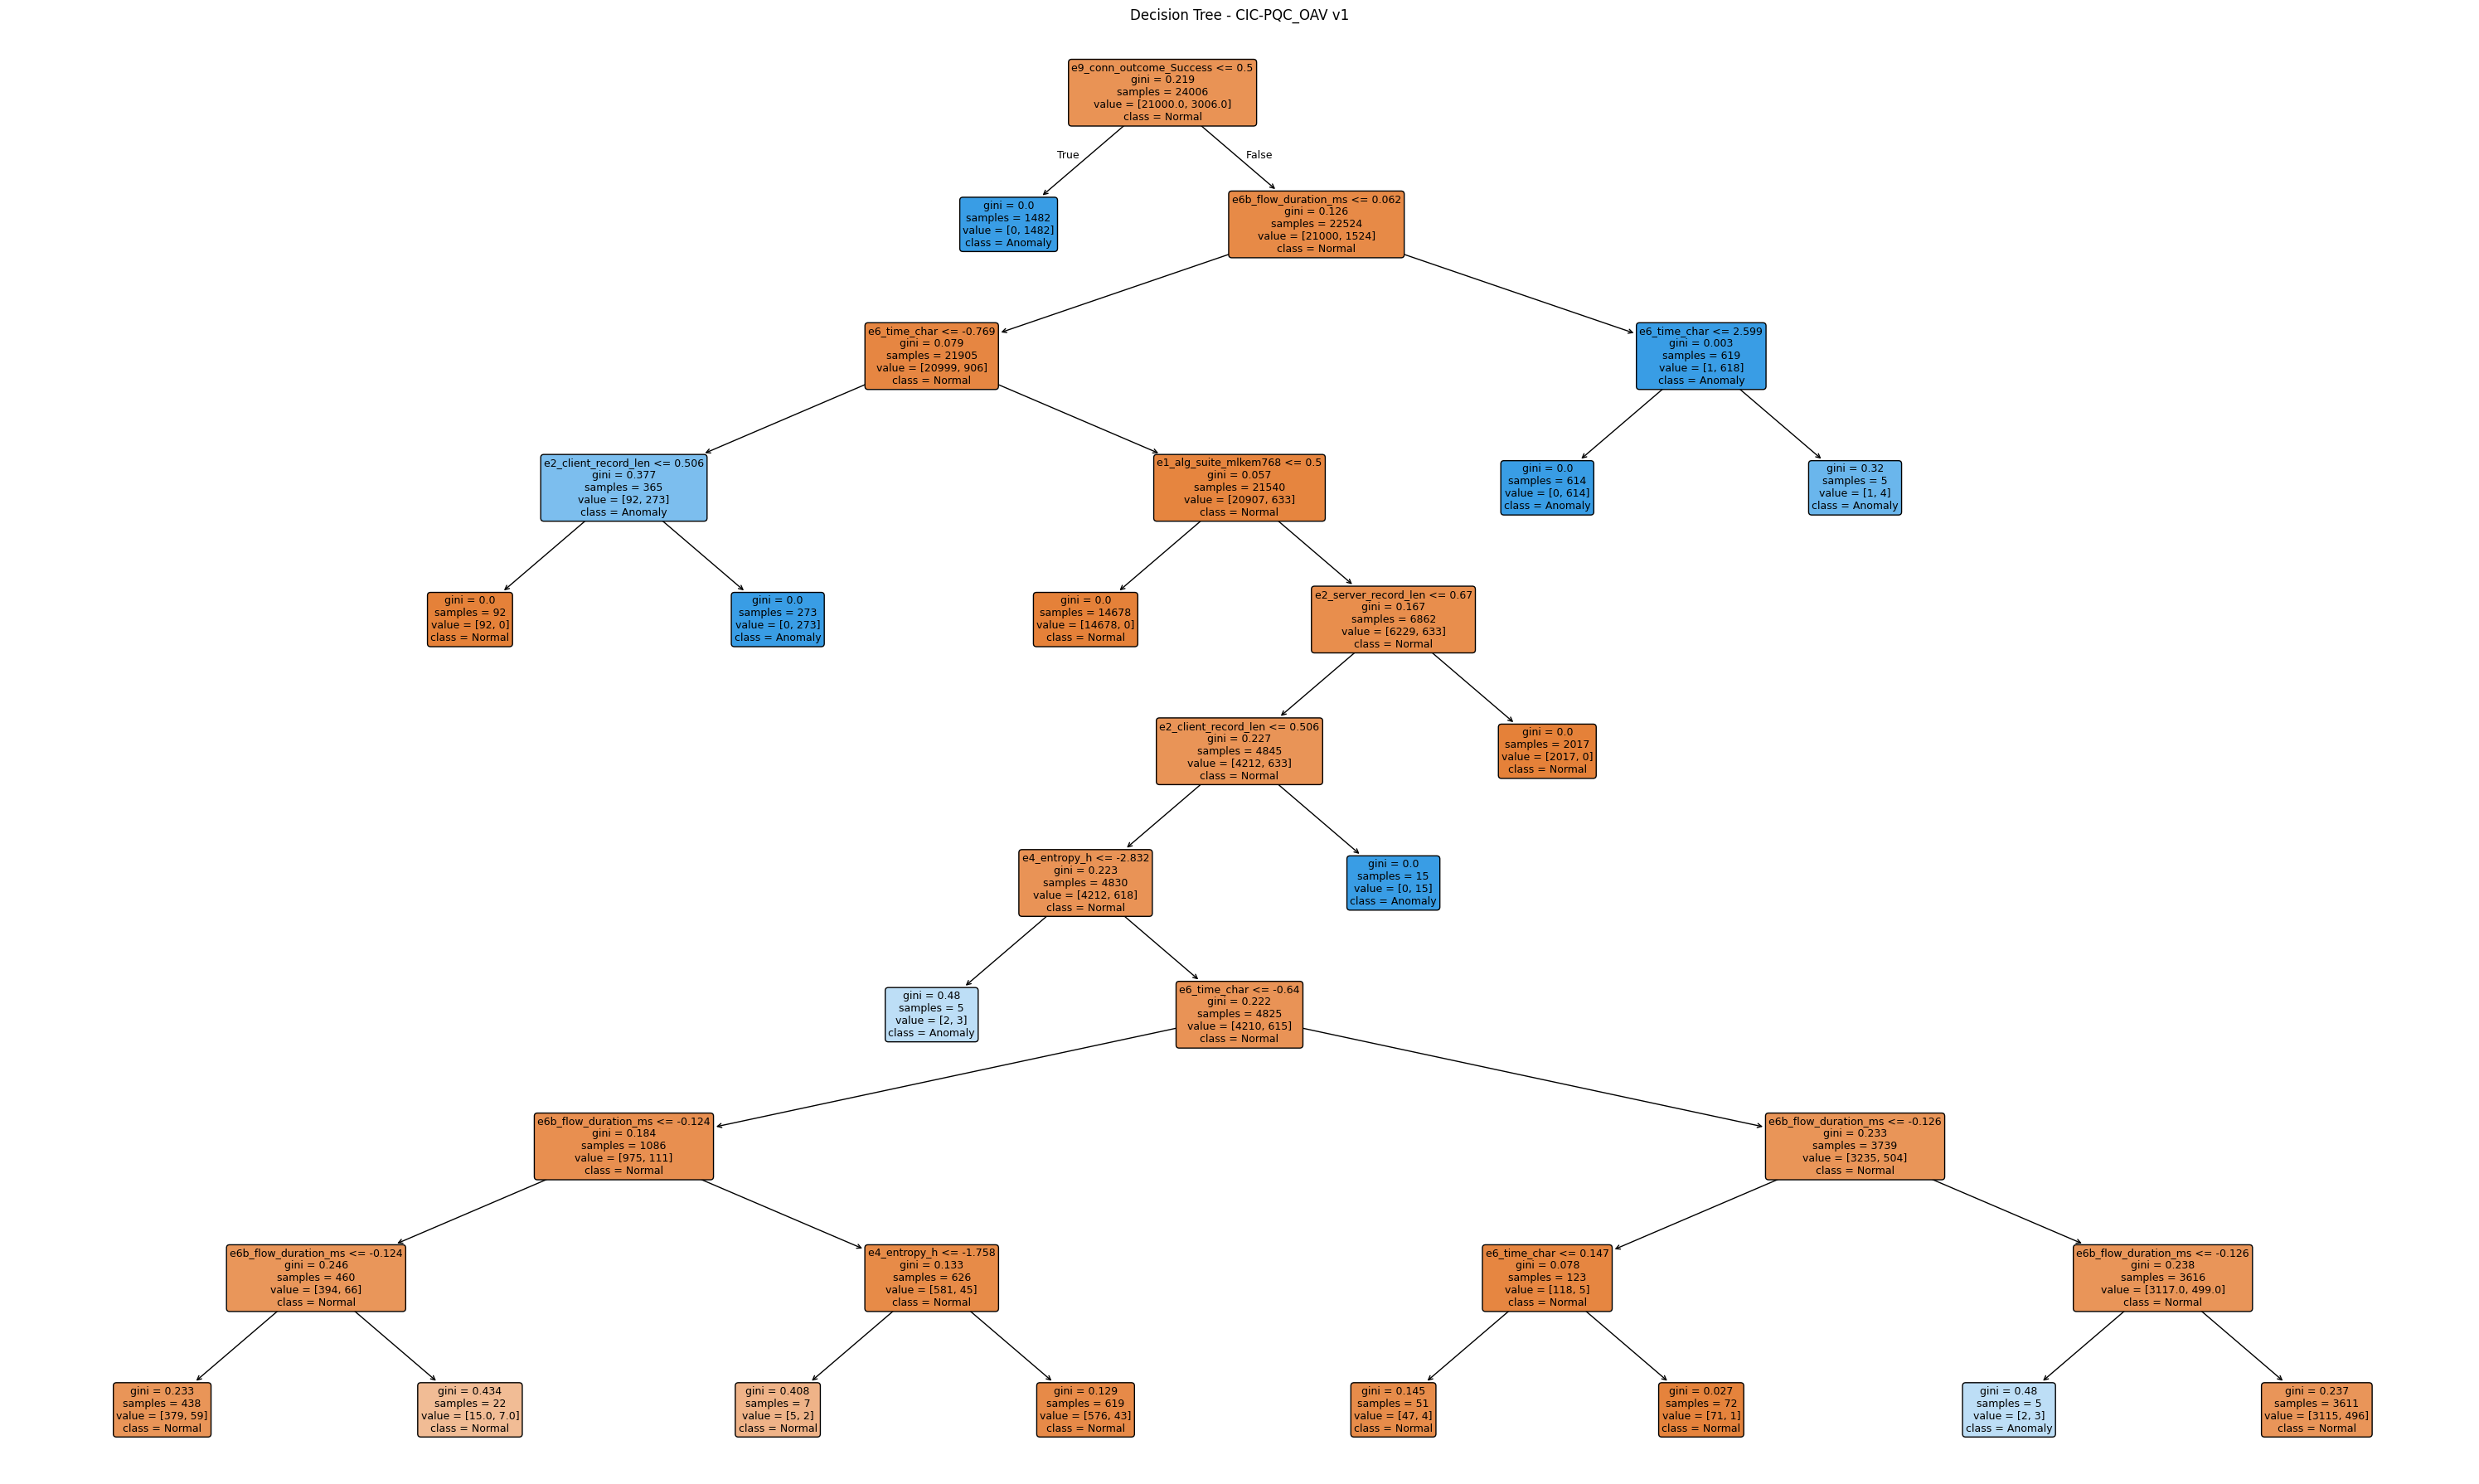

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 18))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=["Normal", "Anomaly"],
    filled=True,
    rounded=True,
    fontsize=9,
    proportion=False
)

plt.title("Decision Tree - CIC-PQC_OAV v1")
plt.tight_layout()
plt.show()

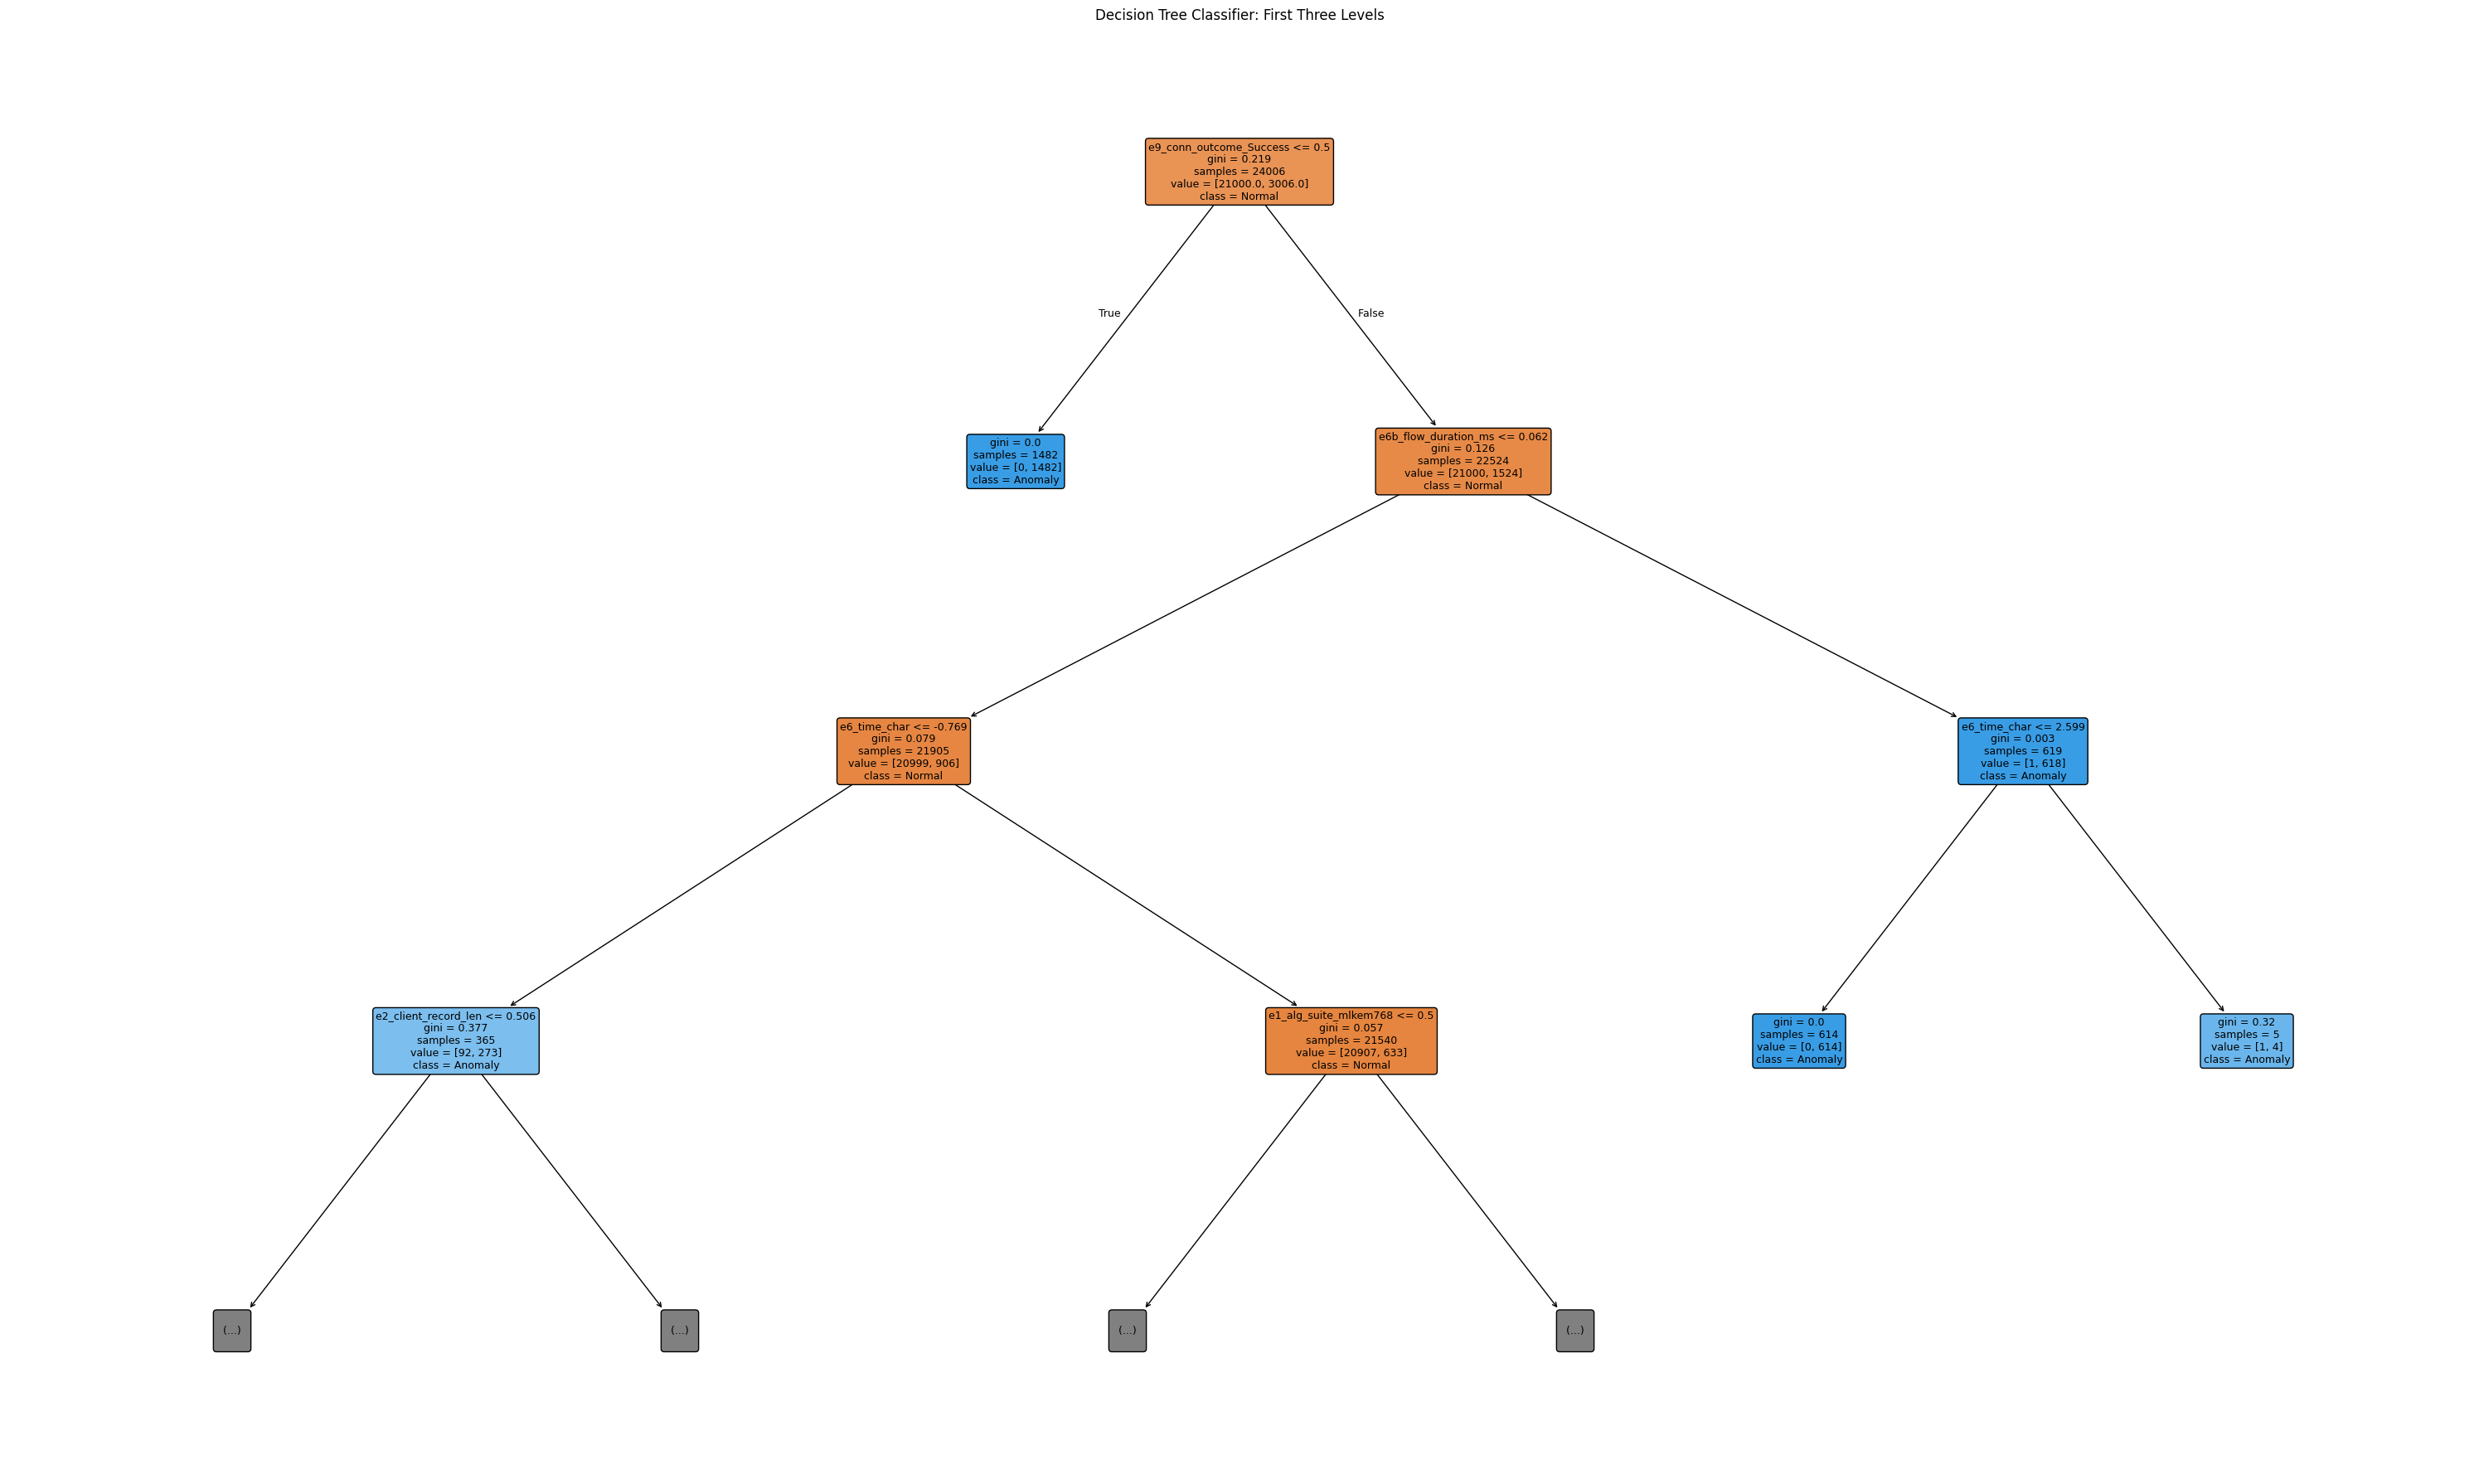

In [7]:
plt.figure(figsize=(30, 18))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=["Normal", "Anomaly"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title(
    "Decision Tree Classifier: First Three Levels"
)

plt.tight_layout()
plt.savefig(
    "decision_tree_first_3_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
split_rows = []

for node in range(tree.node_count):

    feature_index = tree.feature[node]

    if feature_index != _tree.TREE_UNDEFINED:

        left = tree.children_left[node]
        right = tree.children_right[node]

        split_rows.append({
            "Node": node,
            "Feature": feature_names[feature_index],
            "Threshold": tree.threshold[node],
            "Samples at Node": tree.n_node_samples[node],
            "Left Samples": tree.n_node_samples[left],
            "Right Samples": tree.n_node_samples[right],
            "Left %": (
                tree.n_node_samples[left]
                / tree.n_node_samples[node] * 100
            ),
            "Right %": (
                tree.n_node_samples[right]
                / tree.n_node_samples[node] * 100
            )
        })

split_table = pd.DataFrame(split_rows)

display(
    split_table.head(20).round(3)
)


,Node,Feature,Threshold,Samples at Node,Left Samples,Right Samples,Left %,Right %
0,0,e9_conn_outcome_Success,0.500,24006,1482,22524,6.173,93.827
1,2,e6b_flow_duration_ms,0.062,22524,21905,619,97.252,2.748
2,3,e6_time_char,-0.769,21905,365,21540,1.666,98.334
3,4,e2_client_record_len,0.506,365,92,273,25.205,74.795
4,7,e1_alg_suite_mlkem768,0.500,21540,14678,6862,68.143,31.857
5,9,e2_server_record_len,0.670,6862,4845,2017,70.606,29.394
6,10,e2_client_record_len,0.506,4845,4830,15,99.690,0.310
7,11,e4_entropy_h,-2.832,4830,5,4825,0.104,99.896
8,13,e6_time_char,-0.640,4825,1086,3739,22.508,77.492
9,14,e6b_flow_duration_ms,-0.124,1086,460,626,42.357,57.643
